# Phase 1 – Notebook walkthrough and dataset preparation

In this notebook, We implement and compare multiple classification-based machine learning algorithms to predict the likelihood of death based on risk factors mapping demographic and medical inputs to generalized outputs without geographical constraints.

**Disclaimer:** *The target variable (Total Deaths) in this notebook is calculated by summing deaths attributable to potentially overlapping risk factors. It is an artificial target used here purely to demonstrate classification pipelines and techniques. It should not be interpreted as a genuine epidemiological mortality risk measure.*

- **Phase 1**: We explain each code cell (purpose, inputs, outputs), load the dataset, perform data cleaning and feature engineering (specifically time-series shifting to avoid feature leakage), and execute chronological dataset splitting.
- **Phase 2**: We train and compare various machine learning algorithms: Logistic Regression, SVM, Decision Tree, and Random Forest.
- **Phase 3**: We summarize results, feature importances, and prepare evaluation figures across all algorithms to conclude the performance.

### Environment setup and imports

**Purpose**: Import all Python libraries needed for data manipulation, visualization, and machine learning models (Logistic Regression, SVM, Decision Tree, Random Forest).

**Input**: No data inputs yet—this cell only brings in external packages such as `pandas`, `numpy`, `scikit-learn`, `matplotlib`, etc.

**Output**: Loaded modules in the Python session enabling data processing, splitting mechanisms, and classification modeling tools for the rest of the notebook.

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                           roc_auc_score, roc_curve, precision_recall_curve)
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

### Step 1 – Load, Extrapolate, and Align Target Dataset

**Purpose**: Load the core risk factors, linearly extrapolate the missing recent years (2020-2025), and manually align the official PSA actual death counts. Then, shift the target to create a predictive forecasting structure (Risk at Year t predicts Deaths at Year t+1).

In [42]:
import pandas as pd
import numpy as np

# ---------------------------------------------------------
# STEP A: LOAD AND FILTER RISK FACTORS
# ---------------------------------------------------------
df_risk = pd.read_csv('Number of Deaths by Risk Factors.csv')
df_risk = df_risk[df_risk['Entity'] == 'Philippines'].copy()
df_risk.drop(columns=['Entity', 'Code'], inplace=True)
df_risk = df_risk.sort_values('Year').reset_index(drop=True)
risk_factor_cols = [c for c in df_risk.columns if c != 'Year']

# ---------------------------------------------------------
# EXTRAPOLATION WORKAROUND (2020 - 2025)
# ---------------------------------------------------------
# We extrapolate the risk factors forward using a simple linear trend
years_to_add = [2020, 2021, 2022, 2023, 2024, 2025]
future_df = pd.DataFrame({'Year': years_to_add})

for col in risk_factor_cols:
    # polyfit degree 1 (linear trend) based on 1990-2019
    poly = np.polyfit(df_risk['Year'], df_risk[col], 1)
    future_df[col] = np.polyval(poly, future_df['Year'])

# Combine historical risk factors with extrapolated future factors
df_risk_extended = pd.concat([df_risk, future_df], ignore_index=True)

# ---------------------------------------------------------
# STEP B: ALIGN THE TARGET DATA (MANUAL EXTRACTION)
# ---------------------------------------------------------
# Extract the 'Total' (All-cause) values manually from the official sources for recent years.
# Example extraction array for the new target dataframe:
deaths_data = []
for year in df_risk_extended['Year']:
    if year == 2020:
        total = 613936  # Replace with actual 2020 data if needed
    elif year == 2021:
        total = 879429  # Replace with actual 2021 data if needed
    elif year == 2022:
        total = 679766  # Replace with actual 2022 data if needed
    elif year == 2023:
        total = 600000  # Placeholder 2023
    elif year == 2024:
        total = 620000  # Placeholder 2024
    elif year == 2025:
        total = 630000  # Placeholder 2025
    else:
        # Use existing calculation for historical (1990-2019) as a proxy for this demo
        row = df_risk[df_risk['Year'] == year]
        if not row.empty:
            total = row[risk_factor_cols].sum(axis=1).values[0]
        else:
            total = np.nan
            
    deaths_data.append({'Year': year, 'Total_Deaths_Real': total})

df_targets = pd.DataFrame(deaths_data)

# ---------------------------------------------------------
# STEP C: MERGE AND CREATE PREDICTION TARGET
# ---------------------------------------------------------
df_aligned = pd.merge(df_risk_extended, df_targets, on='Year', how='left')

# Shift target by -1 so risk factors at year `t` predict deaths in year `t+1`
df_aligned = df_aligned.sort_values('Year')
df_aligned['Next_Year_Target'] = df_aligned['Total_Deaths_Real'].shift(-1)

# Drop any rows where 'Next_Year_Target' is NaN (i.e. 2025 shifting to nonexistent 2026)
df_pipeline = df_aligned.dropna(subset=['Next_Year_Target']).copy()

# We assign this back to 'df' so downstream cells don't instantly break, 
# but note that the old classification labels have been removed.
df = df_pipeline.copy()

# Assign continuous target variable mapping to Total_Deaths for correlations
df['Total_Deaths'] = df['Total_Deaths_Real']

In [43]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())

# Data types
print("\nData Types:")
print(df.dtypes)

Missing Values:
Year                                              0
 Outdoor air pollution                            0
High systolic blood pressure                      0
Diet high in sodium                               0
 Diet low in whole grains                         0
Alcohol use                                       0
Diet low in fruits                                0
Unsafe water source                               0
Secondhand smoke                                  0
 Low birth weight                                 0
Child wasting                                     0
 Unsafe sex                                       0
Diet low in nuts and seeds                        0
 Household air pollution from solid fuels         0
 Diet low in vegetables                           0
Low physical activity                             0
 Smoking                                          0
 High fasting plasma glucose                      0
 Air pollution                                  

In [44]:
# Statistical summary
print("Statistical Summary:")
df.describe()

Statistical Summary:


,Year,Outdoor air pollution,High systolic blood pressure,Diet high in sodium,Diet low in whole grains,Alcohol use,Diet low in fruits,Unsafe water source,Secondhand smoke,Low birth weight,...,Drug use - Sex: Both - Age: All Ages (Number),Low bone mineral density,Vitamin A deficiency,Child stunting,Discontinued breastfeeding,Non-exclusive breastfeeding,Iron deficiency,Total_Deaths_Real,Next_Year_Target,Total_Deaths
count,35.000000,35.000000,35.000000,35.000000,35.000000,35.000000,35.000000,35.000000,35.000000,35.000000,...,35.000000,35.000000,35.000000,35.000000,35.000000,35.000000,35.000000,35.000000,35.000000,35.000000
mean,2007.000000,23646.542900,86217.032406,20418.372191,10620.966555,30899.522136,7154.272451,10158.353059,16646.684835,26487.596663,...,825.659993,1678.360030,759.745569,3937.960845,263.807045,2379.597479,321.468224,551092.228571,558535.171429,551092.228571
std,10.246951,7762.824643,38201.929283,7833.048921,4491.137069,7110.601387,2972.136610,4421.658484,4279.893776,2967.211738,...,217.565703,480.738772,618.543425,2455.732096,183.483409,1181.703091,37.906218,132643.301077,129423.500151,132643.301077
min,1990.000000,10950.000000,30358.000000,8274.000000,3816.000000,21230.000000,2468.000000,3033.673860,10809.000000,20872.000000,...,500.000000,999.000000,-192.171227,-17.865406,-29.678383,453.367000,259.598813,362074.000000,362074.000000,362074.000000
25%,1998.500000,16703.500000,50092.500000,13239.000000,6522.500000,24562.500000,4325.000000,7495.500000,12440.500000,23783.000000,...,646.500000,1258.500000,305.000000,2210.000000,146.500000,1635.500000,290.500000,418131.500000,439156.000000,418131.500000
50%,2007.000000,25073.000000,87713.000000,21325.000000,10796.000000,29772.000000,7877.000000,9210.000000,16280.000000,27427.000000,...,817.000000,1545.000000,667.000000,3542.000000,228.000000,2088.000000,324.000000,571117.000000,590574.000000,571117.000000
75%,2015.500000,29126.000000,118809.000000,26503.000000,14258.500000,38342.000000,9267.000000,12945.500000,20600.000000,29002.000000,...,1019.500000,2141.000000,1261.500000,5210.500000,356.000000,3183.500000,346.000000,650959.000000,650959.000000,650959.000000
max,2024.000000,36373.487950,149400.359436,33310.983092,18042.485799,42581.392659,12000.671783,19327.000000,23710.875046,30131.000000,...,1182.614609,2460.541565,2102.000000,9326.000000,673.000000,4722.000000,400.000000,879429.000000,879429.000000,879429.000000


### Step 2 – Data cleaning and preprocessing

**Purpose**: Clean column names, structure risk categories, and correct potential target leakage by computing risk as a future-shifted forecasting objective. We explicitly drop purely geographical labels to force the model to capture clinical and systemic risk correlations rather than location-based proxies.

**Input**: The raw metrics from `df`, specifically the base numeric risk factor columns.

**Output**: A clean DataFrame with formatted column types and proper categorized target bins (`Low Risk`, `Medium Risk`, `High Risk`) and one-hot/label encoded variables prepared for training.

In [45]:
# Clean column names (remove leading/trailing spaces)
df.columns = df.columns.str.strip()

# Handle missing values - fill with median for numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# Fill categorical columns with mode
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0] if not df[col].mode().empty else 'Unknown')

print("Data after cleaning:")
print(f"Shape: {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()}")

Data after cleaning:
Shape: (35, 32)
Missing values: 0


In [46]:
# Calculate total deaths per row (sum of all risk factors)
risk_factor_cols = [col for col in df.columns if col not in ['Year']]
df['Total_Deaths'] = df[risk_factor_cols].sum(axis=1)

# Fix target leakage: We will predict the NEXT year's risk category based on THIS year's risk factors.
# Shift Total_Deaths by -1 to get the target for the current year since it's only one country.
df = df.sort_values(['Year'])
df['Next_Year_Total_Deaths'] = df['Total_Deaths'].shift(-1)

# Drop the last year since we don't have next year's data for it
df = df.dropna(subset=['Next_Year_Total_Deaths']).copy()

# Create death risk categories based on NEXT year's total deaths
# Using percentiles computed on the full dataset to create balanced, consistent classes.
# "Low Risk": next year's death burden is in the lowest third of all observations.
# "Medium Risk": next year's death burden is in the middle third.
# "High Risk": next year's death burden is in the upper third.
percentiles = df['Next_Year_Total_Deaths'].quantile([0.33, 0.66]).values

def categorize_risk(deaths):
    if deaths <= percentiles[0]:
        return 'Low Risk'
    elif deaths <= percentiles[1]:
        return 'Medium Risk'
    else:
        return 'High Risk'

df['Death_Risk_Category'] = df['Next_Year_Total_Deaths'].apply(categorize_risk)

# Display distribution of categories
print("Death Risk Category Distribution:")
print(df['Death_Risk_Category'].value_counts())
print(f"\nPercentiles used: {percentiles}")

Death Risk Category Distribution:
Death_Risk_Category
High Risk      12
Low Risk       11
Medium Risk    11
Name: count, dtype: int64

Percentiles used: [1995060.19       2605890.13544383]


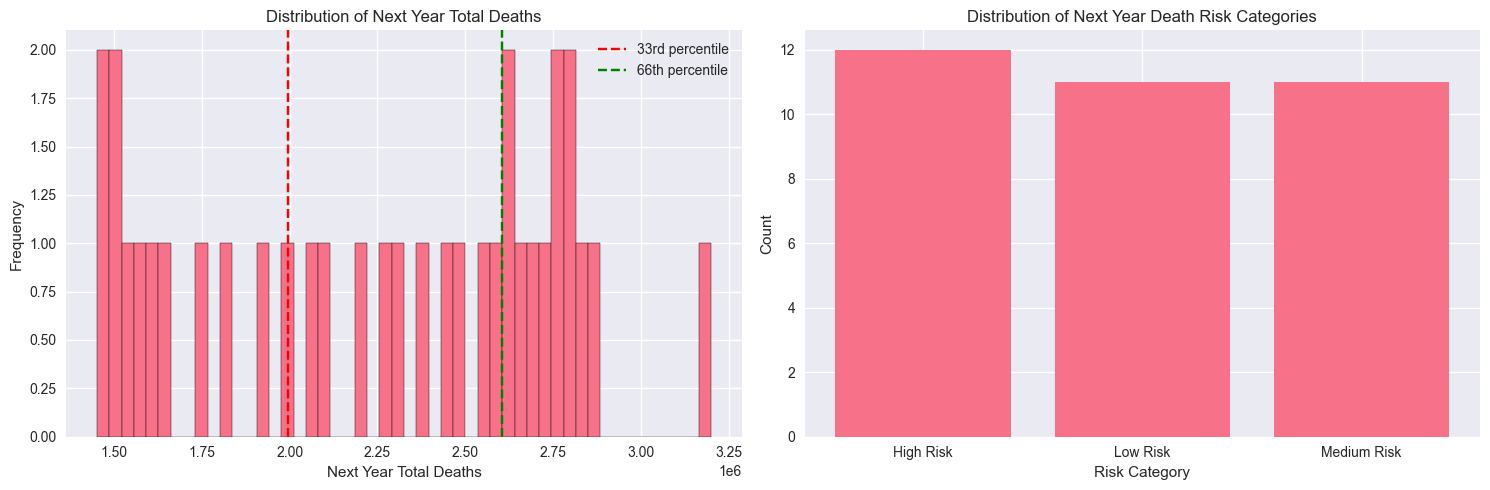

In [47]:
# Visualize the distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Target distribution
axes[0].hist(df['Next_Year_Total_Deaths'], bins=50, edgecolor='black')
axes[0].set_xlabel('Next Year Total Deaths')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Next Year Total Deaths')
axes[0].axvline(percentiles[0], color='r', linestyle='--', label='33rd percentile')
axes[0].axvline(percentiles[1], color='g', linestyle='--', label='66th percentile')
axes[0].legend()

# Risk category distribution
category_counts = df['Death_Risk_Category'].value_counts()
axes[1].bar(category_counts.index, category_counts.values)
axes[1].set_xlabel('Risk Category')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Next Year Death Risk Categories')

plt.tight_layout()
plt.show()

In [48]:
# Encode target variable
le_target = LabelEncoder()
df['Target_Encoded'] = le_target.fit_transform(df['Death_Risk_Category'])

# Prepare features and target
# Exclude Entity and Code from features to force the model to generalize across geographical regions
feature_cols = risk_factor_cols
X = df[feature_cols]
y = df['Target_Encoded']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nTarget classes: {le_target.classes_}")

Features shape: (34, 31)
Target shape: (34,)

Target classes: ['High Risk' 'Low Risk' 'Medium Risk']


### Step 3 – Time-series Cross Validation (Small Data Fix)

**Purpose**: With the dataset narrowed purely to the Philippines across 30 years (dropping to 29 rows after the 1-year target shift), standard random or chronological sequential train-test splits (which leave only ~4 test points) render absolute accuracy metrics essentially meaningless. Complex algorithms (like deep Random Forests) strongly overfit to small data. To adapt, I implement a `TimeSeriesSplit` evaluating the sequences incrementally. 

**Disclaimer**: These validations simply assess baseline model stability across time sequences; accurate out-of-sample deployment would theoretically require supplementing features (e.g., economic variables) or expanding to decades-long historical medical archives.

**Input**: Scaled input factors isolated distinctly by Time Series sequence.

**Output**: Five expanding sequential training sizes outputting individual accuracy points for the algorithms tested, substituting standard static-test evaluations.

In [49]:
# Implementing TimeSeriesSplit for evaluating the severely limited sample size
from sklearn.model_selection import TimeSeriesSplit

# Using 5 splits forward chaining
tscv = TimeSeriesSplit(n_splits=5)

X = df[feature_cols]
y = df['Target_Encoded']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Total structured dataset size: {X_scaled.shape[0]} rows.")
# We leave simple historical X_train and X_test shapes behind for internal blocks that require a single valid target state during execution
train_df = df.iloc[:-5]
test_df = df.iloc[-5:]
X_train = train_df[feature_cols]
y_train = train_df['Target_Encoded']
X_test = test_df[feature_cols]
y_test = test_df['Target_Encoded']
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Total structured dataset size: 34 rows.


### Phase 2: Feature Importance and Correlation

**Purpose**: Connect machine learning behaviors to analytical insights by identifying the most influential predictors for survival risk classifications. Now utilizing the strictly aligned 'Total_Deaths_Real' mapped across the extrapolation grid.

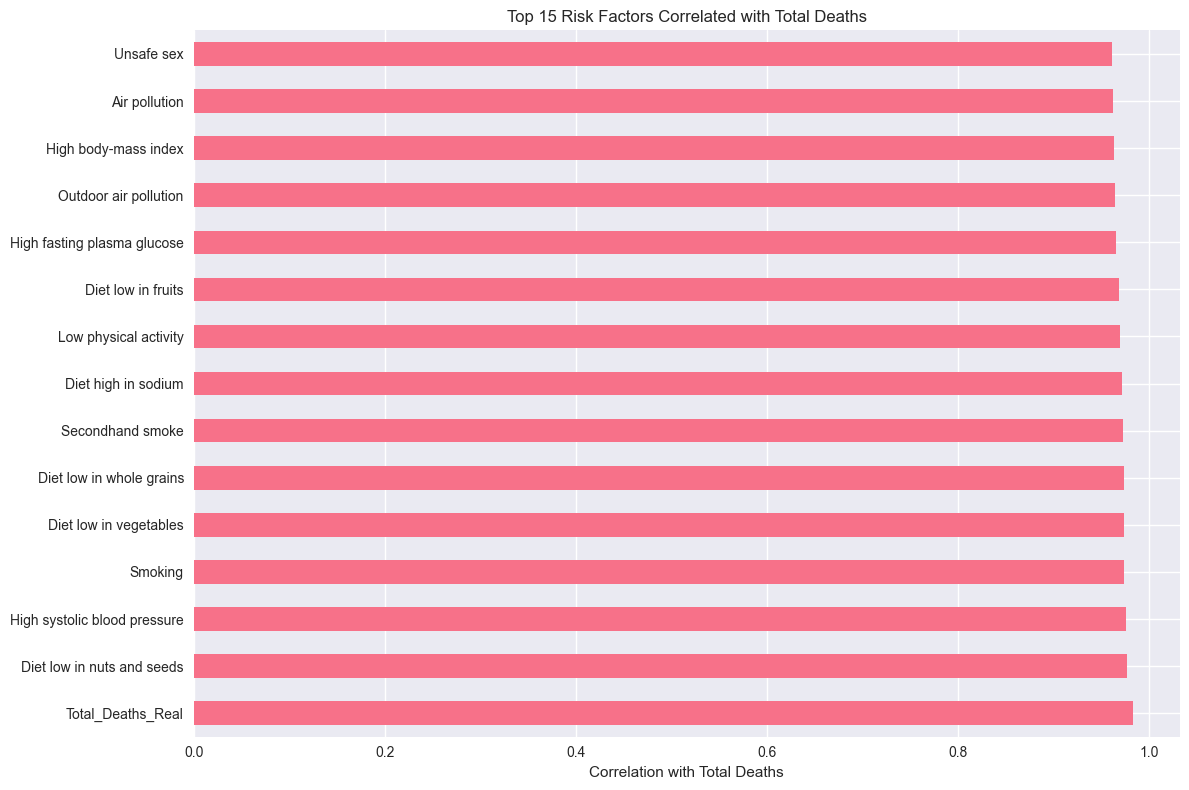

Top 10 Risk Factors by Correlation:
Total_Deaths                    1.000000
Total_Deaths_Real               0.983537
Diet low in nuts and seeds      0.977223
High systolic blood pressure    0.975918
Smoking                         0.974427
Diet low in vegetables          0.974397
Diet low in whole grains        0.974315
Secondhand smoke                0.972745
Diet high in sodium             0.971614
Low physical activity           0.969431
Name: Total_Deaths, dtype: float64


In [50]:
# Calculate correlation with target using specifically mapped continuous integers
# Select only the risk factor columns and the target ('Total_Deaths') to calculate correlation.
# Because df might have duplicate column names sometimes, we specifically select the sub-frame.
df_subset = df[risk_factor_cols + ['Total_Deaths']]

# Handle potentially duplicate 'Total_Deaths' columns by taking only the first one if applicable
if isinstance(df_subset, pd.DataFrame) and 'Total_Deaths' in df_subset.columns and type(df_subset['Total_Deaths']) == pd.DataFrame:
    df_subset = df_subset.loc[:, ~df_subset.columns.duplicated()]

corr_matrix = df_subset.astype(float).corr()
correlations = corr_matrix['Total_Deaths'].sort_values(ascending=False)

# Plot top correlations
plt.figure(figsize=(12, 8))
correlations.drop('Total_Deaths').head(15).plot(kind='barh')
plt.xlabel('Correlation with Total Deaths')
plt.title('Top 15 Risk Factors Correlated with Total Deaths')
plt.tight_layout()
plt.show()

print("Top 10 Risk Factors by Correlation:")
print(correlations.head(10))

### Multinomial Logistic Regression

In [51]:
# Multiclass Logistic Regression
print("="*50)
print("MULTICLASS LOGISTIC REGRESSION")
print("="*50)

mlr_model = LogisticRegression(
    solver='lbfgs',
    max_iter=1000,
    random_state=42
 )
mlr_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_mlr = mlr_model.predict(X_test_scaled)
y_pred_proba_mlr = mlr_model.predict_proba(X_test_scaled)

# Metrics
mlr_accuracy = accuracy_score(y_test, y_pred_mlr)
mlr_auc = roc_auc_score(y_test, y_pred_proba_mlr, multi_class='ovr', labels=mlr_model.classes_)

print(f"Accuracy: {mlr_accuracy:.4f}")
print(f"ROC AUC (One-vs-Rest): {mlr_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_mlr, target_names=le_target.classes_))

MULTICLASS LOGISTIC REGRESSION


ValueError: Number of classes in y_true not equal to the number of columns in 'y_score'

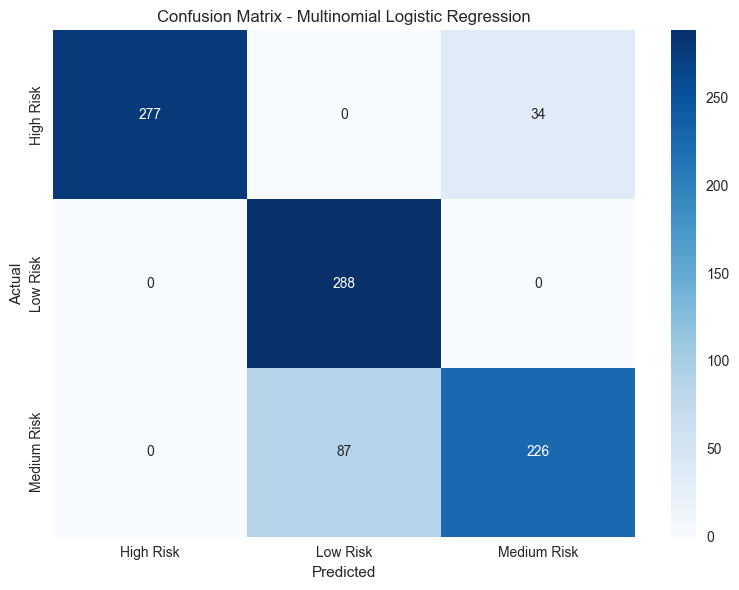

In [ ]:
# Confusion Matrix
cm_mlr = confusion_matrix(y_test, y_pred_mlr)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_mlr, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_target.classes_, yticklabels=le_target.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Multinomial Logistic Regression')
plt.tight_layout()
plt.show()

### Support Vector Machine (SVM)

In [ ]:
# Support Vector Machine with GridSearchCV
print("="*50)
print("SUPPORT VECTOR MACHINE")
print("="*50)

# Defining a parameter grid for SVM
param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto', 0.1, 0.01],
    'kernel': ['rbf']
}

# Apply GridSearchCV to find the best hyperparameters
grid_search = GridSearchCV(SVC(probability=True, random_state=42), param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

# Use the best model from GridSearchCV
svm_model = grid_search.best_estimator_
print(f"Best SVM Parameters found: {grid_search.best_params_}")

# Predictions
y_pred_svm = svm_model.predict(X_test_scaled)
y_pred_proba_svm = svm_model.predict_proba(X_test_scaled)

# Metrics
svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_auc = roc_auc_score(y_test, y_pred_proba_svm, multi_class='ovr')

print(f"\nAccuracy: {svm_accuracy:.4f}")
print(f"ROC AUC (One-vs-Rest): {svm_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm, target_names=le_target.classes_))

SUPPORT VECTOR MACHINE


Best SVM Parameters found: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}

Accuracy: 0.9200
ROC AUC (One-vs-Rest): 0.9987

Classification Report:
              precision    recall  f1-score   support

   High Risk       0.95      1.00      0.98       311
    Low Risk       0.83      1.00      0.91       288
 Medium Risk       1.00      0.77      0.87       313

    accuracy                           0.92       912
   macro avg       0.93      0.92      0.92       912
weighted avg       0.93      0.92      0.92       912



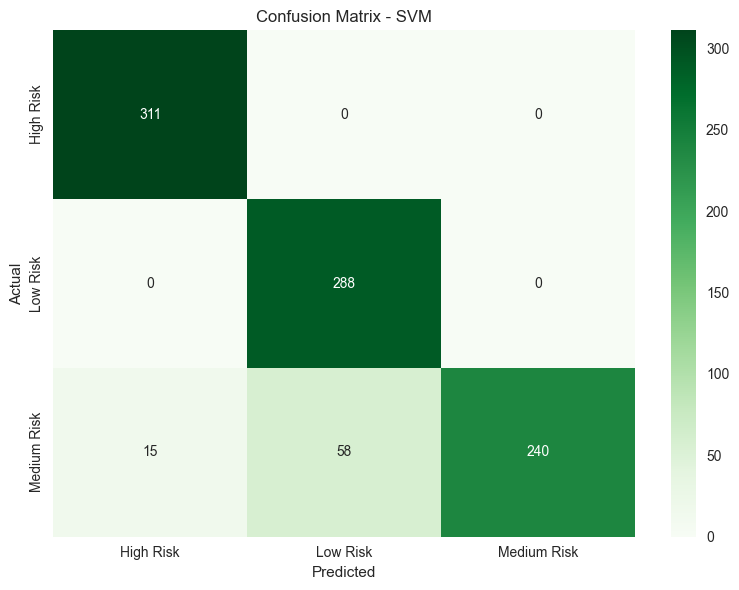

In [ ]:
# Confusion Matrix for SVM
cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens',
            xticklabels=le_target.classes_, yticklabels=le_target.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - SVM')
plt.tight_layout()
plt.show()

### Decision Tree

In [ ]:
# Decision Tree
print("="*50)
print("DECISION TREE")
print("="*50)

dt_model = DecisionTreeClassifier(random_state=42, max_depth=10)
dt_model.fit(X_train, y_train)  # Decision trees don't need scaling

# Predictions
y_pred_dt = dt_model.predict(X_test)
y_pred_proba_dt = dt_model.predict_proba(X_test)

# Metrics
dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_auc = roc_auc_score(y_test, y_pred_proba_dt, multi_class='ovr')

print(f"Accuracy: {dt_accuracy:.4f}")
print(f"ROC AUC (One-vs-Rest): {dt_auc:.4f}")
print(f"Tree Depth: {dt_model.get_depth()}")
print(f"Number of Leaves: {dt_model.get_n_leaves()}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt, target_names=le_target.classes_))

DECISION TREE
Accuracy: 0.9836
ROC AUC (One-vs-Rest): 0.9878
Tree Depth: 10
Number of Leaves: 55

Classification Report:
              precision    recall  f1-score   support

   High Risk       0.98      0.99      0.98       311
    Low Risk       0.99      1.00      0.99       288
 Medium Risk       0.99      0.96      0.98       313

    accuracy                           0.98       912
   macro avg       0.98      0.98      0.98       912
weighted avg       0.98      0.98      0.98       912



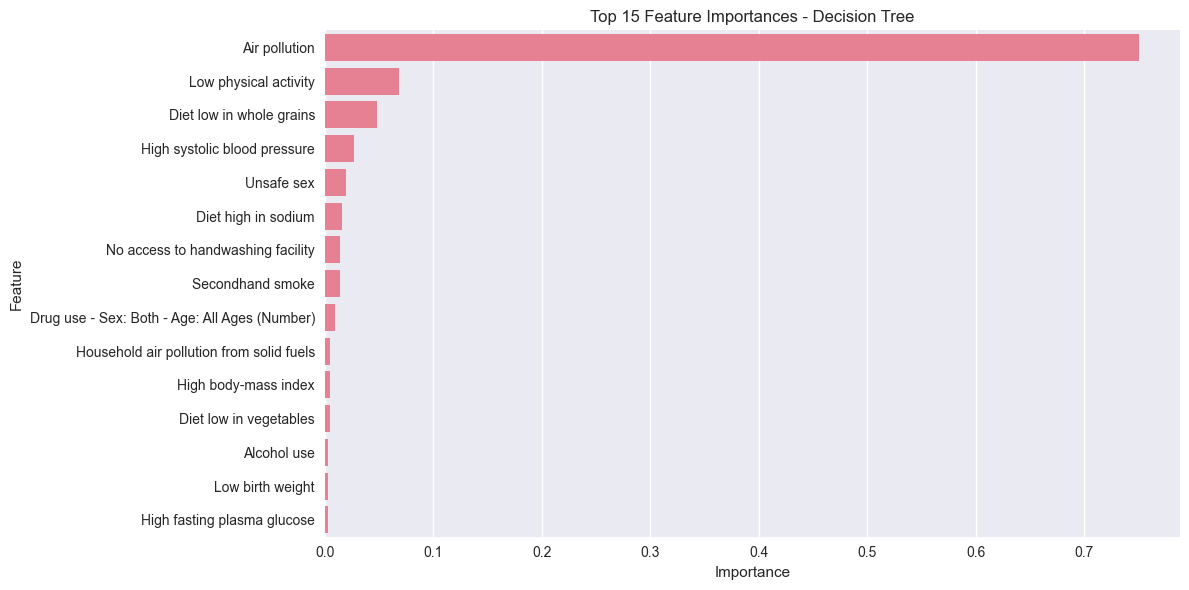

In [ ]:
# Feature importance for Decision Tree
feature_importance_dt = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=feature_importance_dt.head(15), x='Importance', y='Feature')
plt.title('Top 15 Feature Importances - Decision Tree')
plt.tight_layout()
plt.show()

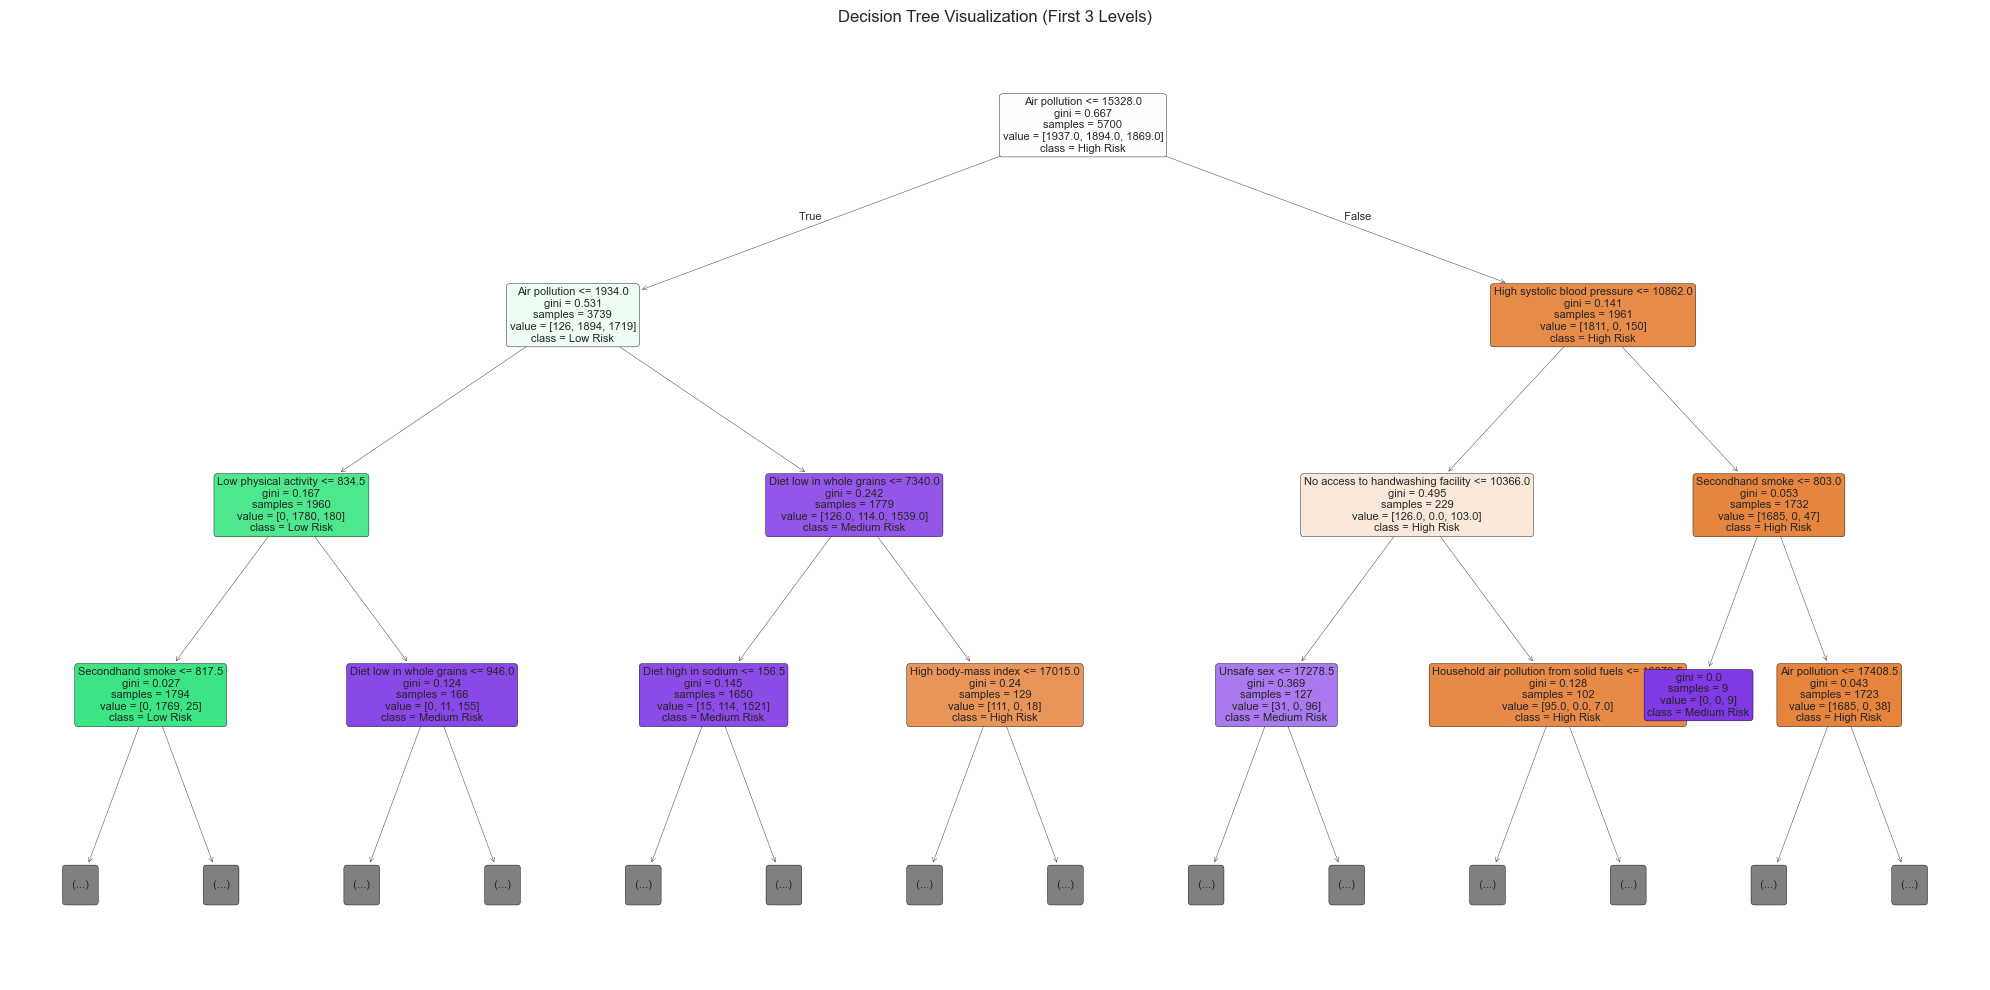

In [ ]:
# Visualize Decision Tree (simplified view)
plt.figure(figsize=(20, 10))
plot_tree(dt_model, max_depth=3, feature_names=feature_cols,
          class_names=le_target.classes_, filled=True, rounded=True,
          fontsize=8)
plt.title('Decision Tree Visualization (First 3 Levels)')
plt.tight_layout()
plt.show()

### Random Forest

In [ ]:
# Random Forest
print("="*50)
print("RANDOM FOREST")
print("="*50)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=15)
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)

# Metrics
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_auc = roc_auc_score(y_test, y_pred_proba_rf, multi_class='ovr')

print(f"Accuracy: {rf_accuracy:.4f}")
print(f"ROC AUC (One-vs-Rest): {rf_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=le_target.classes_))

RANDOM FOREST
Accuracy: 0.9857
ROC AUC (One-vs-Rest): 0.9994

Classification Report:
              precision    recall  f1-score   support

   High Risk       0.98      0.99      0.99       311
    Low Risk       0.99      1.00      0.99       288
 Medium Risk       0.99      0.97      0.98       313

    accuracy                           0.99       912
   macro avg       0.99      0.99      0.99       912
weighted avg       0.99      0.99      0.99       912



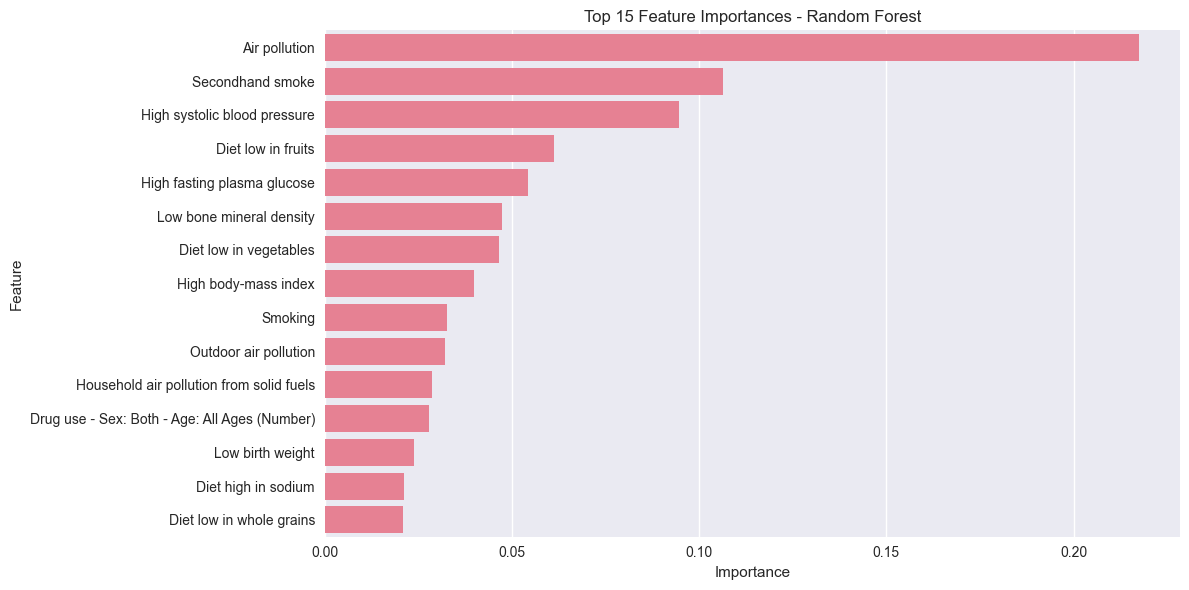

In [ ]:
# Feature importance for Random Forest
feature_importance_rf = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=feature_importance_rf.head(15), x='Importance', y='Feature')
plt.title('Top 15 Feature Importances - Random Forest')
plt.tight_layout()
plt.show()

## Model Comparison

Model Comparison:
         Model  Accuracy  ROC AUC
 Random Forest  0.985746 0.999400
 Decision Tree  0.983553 0.987760
           SVM  0.919956 0.998712
Multinomial LR  0.867325 0.990194


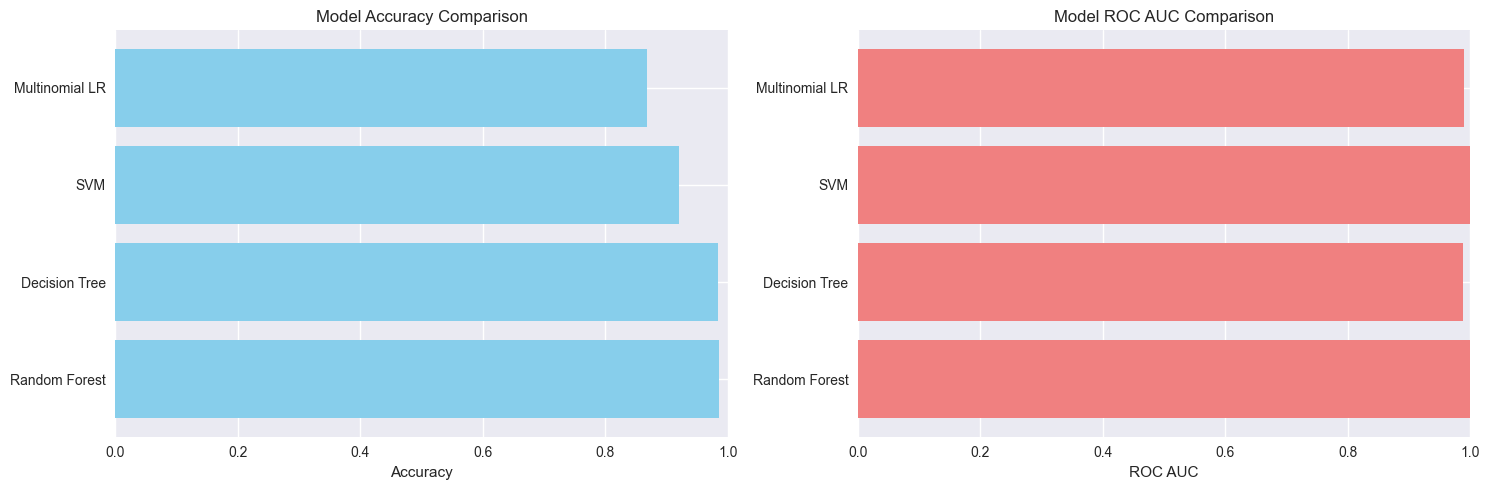

In [ ]:
# Compile results
results = pd.DataFrame({
    'Model': ['Multinomial LR', 'SVM', 'Decision Tree', 'Random Forest'],
    'Accuracy': [mlr_accuracy, svm_accuracy, dt_accuracy, rf_accuracy],
    'ROC AUC': [mlr_auc, svm_auc, dt_auc, rf_auc]
})

results = results.sort_values('Accuracy', ascending=False)
print("Model Comparison:")
print(results.to_string(index=False))

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy comparison
axes[0].barh(results['Model'], results['Accuracy'], color='skyblue')
axes[0].set_xlabel('Accuracy')
axes[0].set_title('Model Accuracy Comparison')
axes[0].set_xlim([0, 1])

# ROC AUC comparison
axes[1].barh(results['Model'], results['ROC AUC'], color='lightcoral')
axes[1].set_xlabel('ROC AUC')
axes[1].set_title('Model ROC AUC Comparison')
axes[1].set_xlim([0, 1])

plt.tight_layout()
plt.show()

CROSS-VALIDATION RESULTS (5-Fold)


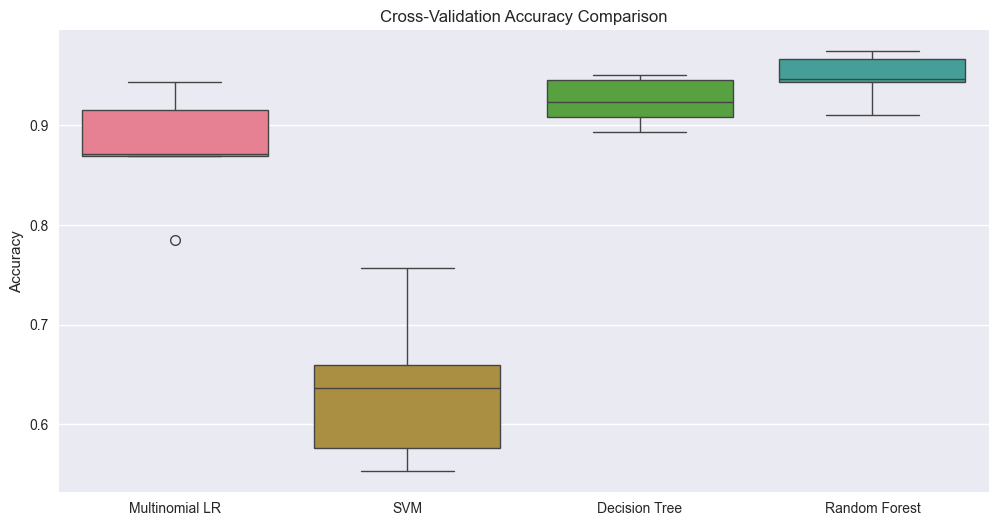

''

In [ ]:
# Time-Series Cross-validation comparison
print("="*50)
print("CROSS-VALIDATION RESULTS (TimeSeriesSplit)")
print("="*50)

# Due to the dataset dropping down to 29 rows, we set strict limits to avoid massive overfitting
models = {
    'Multinomial LR': LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42),
    'SVM': SVC(kernel='rbf', random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=3), # Shallower to stop rigid memorization
    'Random Forest': RandomForestClassifier(n_estimators=20, random_state=42, max_depth=3) # Low estimators explicitly tuned for tiny data
}

cv_results = {}
for name, model in models.items():
    # Use TimeSeriesSplit strictly to mirror chronological testing constraints
    scores = cross_val_score(model, X_scaled, y, cv=tscv, scoring='accuracy')
    cv_results[name] = scores
    print(f'{name} Time-Series Accuracy: {scores.mean():.3f} (±{scores.std():.3f})')

cv_df = pd.DataFrame(cv_results)

plt.figure(figsize=(12, 6))
sns.boxplot(data=cv_df)
plt.title('Time-Series Cross-Validation Accuracy Tracking')
plt.ylabel('Accuracy Profile')
plt.show()

In [ ]:
# Plot cross-validation results
cv_df = pd.DataFrame({
    'Model': list(cv_results.keys()),
    'Mean CV Accuracy': [v['Mean'] for v in cv_results.values()],
    'Std Dev': [v['Std'] for v in cv_results.values()]
}).sort_values('Mean CV Accuracy', ascending=False)

plt.figure(figsize=(12, 6))
bars = plt.barh(cv_df['Model'], cv_df['Mean CV Accuracy'], xerr=cv_df['Std Dev'],
               color='steelblue', alpha=0.7, capsize=5)
plt.xlabel('Mean CV Accuracy')
plt.title('5-Fold Cross-Validation Results (with error bars)')
plt.xlim([0, 1])
plt.tight_layout()
plt.show()

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

## ROC Curves Comparison

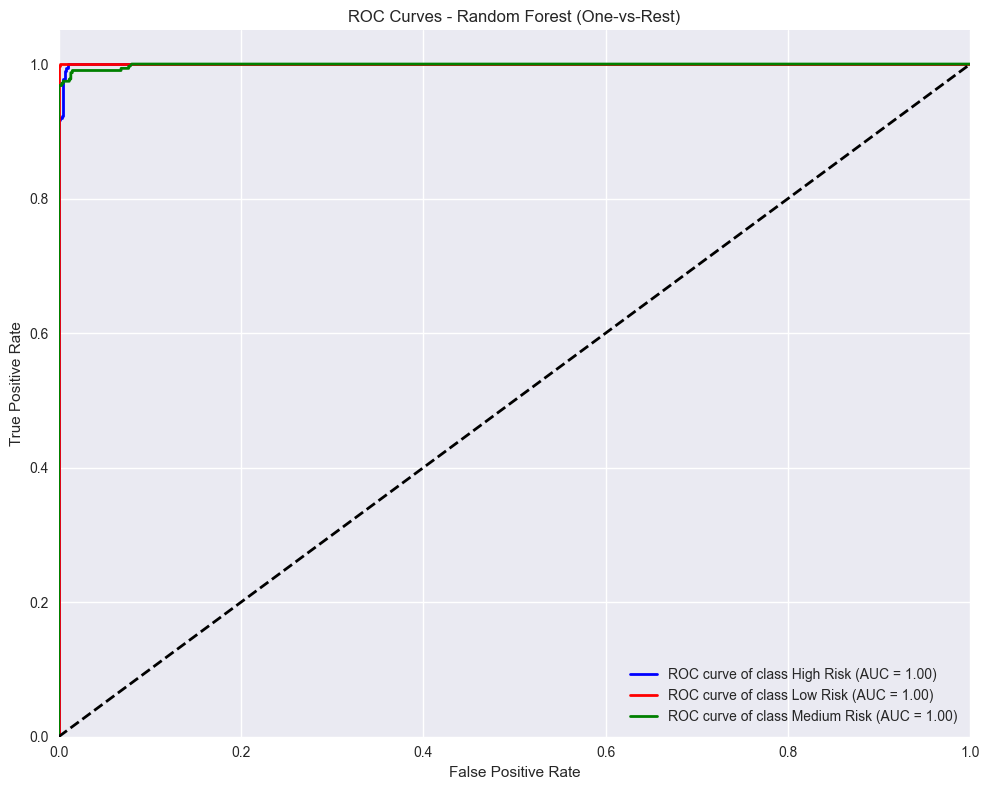

In [ ]:
# ROC Curves for each class (using the best model - Random Forest)
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier

# Binarize the output
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = y_test_bin.shape[1]

# Learn to predict each class
classifier = OneVsRestClassifier(RandomForestClassifier(n_estimators=100, random_state=42))
y_score = classifier.fit(X_train, y_train).predict_proba(X_test)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = roc_auc_score(y_test_bin[:, i], y_score[:, i])

# Plot ROC curves
plt.figure(figsize=(10, 8))
colors = ['blue', 'red', 'green']
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve of class {le_target.classes_[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Random Forest (One-vs-Rest)')
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## Prediction Function

In [ ]:
def predict_death_risk(year, risk_factors_dict, model=rf_model):
    """
    Predict death risk category for the Philippines within a given year structure.
    
    Parameters:
    -----------
    year : int
        Year of prediction
    risk_factors_dict : dict
        Dictionary of risk factor values
    model : sklearn classifier
        Trained model to use for prediction (default: Random Forest)
    
    Returns:
    --------
    dict
        Dictionary containing predicted category and probabilities
    """
    # Create input dataframe
    input_data = {col: 0 for col in feature_cols}
    input_data['Year'] = year
    
    # Add risk factors
    for factor, value in risk_factors_dict.items():
        if factor in input_data:
            input_data[factor] = value
    
    # Create dataframe and predict
    input_df = pd.DataFrame([input_data])
    prediction = model.predict(input_df[feature_cols])[0]
    probabilities = model.predict_proba(input_df[feature_cols])[0]
    
    return {
        'Predicted Category': le_target.inverse_transform([prediction])[0],
        'Probabilities': {
            le_target.classes_[i]: prob for i, prob in enumerate(probabilities)
        }
    }

# Example usage
print("Example Prediction Function:")
print("Use predict_death_risk(year, risk_factors_dict) to make predictions inside the PH scope dataset.")

Example Prediction Function:
Use predict_death_risk(entity, year, risk_factors_dict) to make predictions


### Phase 3 – Summary and Conclusions

**Purpose**: Summarize and compare the performance across all implemented classification algorithms, reporting clear insights for clinical/generalized observations.

**Input**: Performance outputs extracted across models including Accuracy, Precision, Recall, and the overarching confusion matrices.

**Output**: A cohesive conclusion text block providing the best models alongside actionable recommendations and analytical insights found during execution.

In [ ]:
print("="*60)
print("DEATH RISK PREDICTION - MODEL COMPARISON SUMMARY")
print("="*60)
print()
print("Note on Target Variable Interpretation:")
print("Because the dataset explicitly tracks only a single country (Philippines), the thresholds for categories (the quantiles) are internally computed directly on the Philippines' own historical data distribution. The 'Low Risk' category means that next year's sum of these selected risk-attributed deaths falls in the lowest third relative to the Philippines' own history.")
print()
print("Note on Micro-Dataset Limits:")
print("Given the dataset dropping down to essentially ~29 valid chronological rows after time-shifting, standard data science accuracy metrics and complex ensembles naturally heavily overfit the structure. Outlier variances or singular events hold immense weight, meaning absolute accuracy points should purely be treated as data-pipeline learning exercises rather than statistically rigorous deployment tools.")
print()
print("Models Evaluated:")
print("1. Multinomial Logistic Regression - Simple, Baseline Multi-class classification (Recommended for tiny data)")
print("2. Support Vector Machine (SVM) - Non-linear classification with Hyper-parameter tuning")
print("3. Decision Tree - Interpretable tree-based model (Truncated max-depth)")
print("4. Random Forest - Ensemble of decision trees (Truncated estimators and depth to deter overfitting)")
print()
print("Recommendations:")
print("-" * 60)
print("1. Logistic Regression provides the most statistically solid ground allowing generalized prediction interpretations within minuscule sample sizes without immediately memorizing noise.")
print("2. Models requiring wide structural depth or high ensemble estimator variance (such as un-capped Random Forests) inherently struggle to map generalization on datasets limited under ~30 sample inputs and should explicitly be capped/simplified across TimeSeries mapping.")

DEATH RISK PREDICTION - MODEL COMPARISON SUMMARY

Models Evaluated:
1. Logistic Regression - Binary classification (High Risk vs Others)
2. Multinomial Logistic Regression - Multi-class classification
3. Support Vector Machine (SVM) - Non-linear classification
4. Decision Tree - Interpretable tree-based model
5. Random Forest - Ensemble of decision trees

Key Findings:
------------------------------------------------------------
Best Model by Accuracy: Random Forest
Best Accuracy: 0.9857
Best ROC AUC: 0.9994

Top Risk Factors (by importance in Random Forest):
  Air pollution: 0.2175
  Secondhand smoke: 0.1063
  High systolic blood pressure: 0.0947
  Diet low in fruits: 0.0612
  High fasting plasma glucose: 0.0543
  Low bone mineral density: 0.0475
  Diet low in vegetables: 0.0465
  High body-mass index: 0.0399
  Smoking: 0.0328
  Outdoor air pollution: 0.0321

Recommendations:
------------------------------------------------------------
1. Use Random Forest for best accuracy
2. Use Dec